Day 1 — Math & Intuition for CNNs
================================
Topics covered:
  1. Manual 2D convolution (numpy) vs PyTorch conv2d
  2. Effect of kernel type (edge, blur, sharpen)
  3. Output size formula verification
  4. Stride and padding effects
  5. Receptive field growth across layers
  6. BatchNorm — what it actually does to activations
  7. ReLU vs Sigmoid vs Tanh — gradient flow comparison
  8. Feature maps — one image, many kernels
  9. Max pooling — spatial compression
  10. Full ConvBlock forward pass with shape tracking


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import os

os.makedirs("outputs",exist_ok=True)



In [2]:
# 1. MANUAL 2D CONVOLUTION vs PYTORCH
#MANUAL
def manual_2dconv(image:np.ndarray, kernel:np.ndarray,padding:int=0)->np.ndarray:
    """
    Formula: Output(i,j) = sum over m,n of [ Image(i+m, j+n) * Kernel(m,n) ]
    """
    H,W = image.shape
    K = kernel.shape[0] #kernel is a square (KxK)

    if padding>0 :
        image = np.pad(image,padding,mode='constant',constant_values=0)
        H,W = image.shape

    out_H = H - K + 1
    out_W = W - K + 1  # Output size formula: floor((W - K + 2P) / S) + 1  (S=1 here)
    output = np.zeros((out_H,out_W))

    for i in range(out_H):
        for j in range(out_W):
            patch = image[i:i+K, j:j+K] #the patch where kernel currently sits
            output[i,j] = np.sum(patch*kernel)
    return output

image_np = np.array([
    [1, 2, 3, 4, 5],
    [6, 7, 8, 9, 10],
    [11,12,13,14,15],
    [16,17,18,19,20],
    [21,22,23,24,25]
], dtype=np.float32)

#Sobel vertical edge kernel
vertical_edge_kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

manual_out = manual_2dconv(image_np,vertical_edge_kernel)
print("\nInput image (5x5):")
print(image_np)
print("\nVertical edge kernel (3x3):")
print(vertical_edge_kernel)
print("\nManual convolution output (3x3):")
print(manual_out)

#PYTORCH
image_t = torch.tensor(image_np)[None,None,:,:] #(1,1,5,5), torch conv2d expects input in (N,C,H,W)
kernel_t = torch.tensor(vertical_edge_kernel)[None,None,:,:]  # (1,1,3,3)
torch_out = F.conv2d(image_t,kernel_t,padding = 0)
print("\nPyTorch conv2d output (3x3):")
print(torch_out.squeeze().numpy())

match = np.allclose(manual_out,torch_out.squeeze().numpy())
print(f"\n✓ Manual vs PyTorch match: {match}")




Input image (5x5):
[[ 1.  2.  3.  4.  5.]
 [ 6.  7.  8.  9. 10.]
 [11. 12. 13. 14. 15.]
 [16. 17. 18. 19. 20.]
 [21. 22. 23. 24. 25.]]

Vertical edge kernel (3x3):
[[-1.  0.  1.]
 [-1.  0.  1.]
 [-1.  0.  1.]]

Manual convolution output (3x3):
[[6. 6. 6.]
 [6. 6. 6.]
 [6. 6. 6.]]

PyTorch conv2d output (3x3):
[[6. 6. 6.]
 [6. 6. 6.]
 [6. 6. 6.]]

✓ Manual vs PyTorch match: True


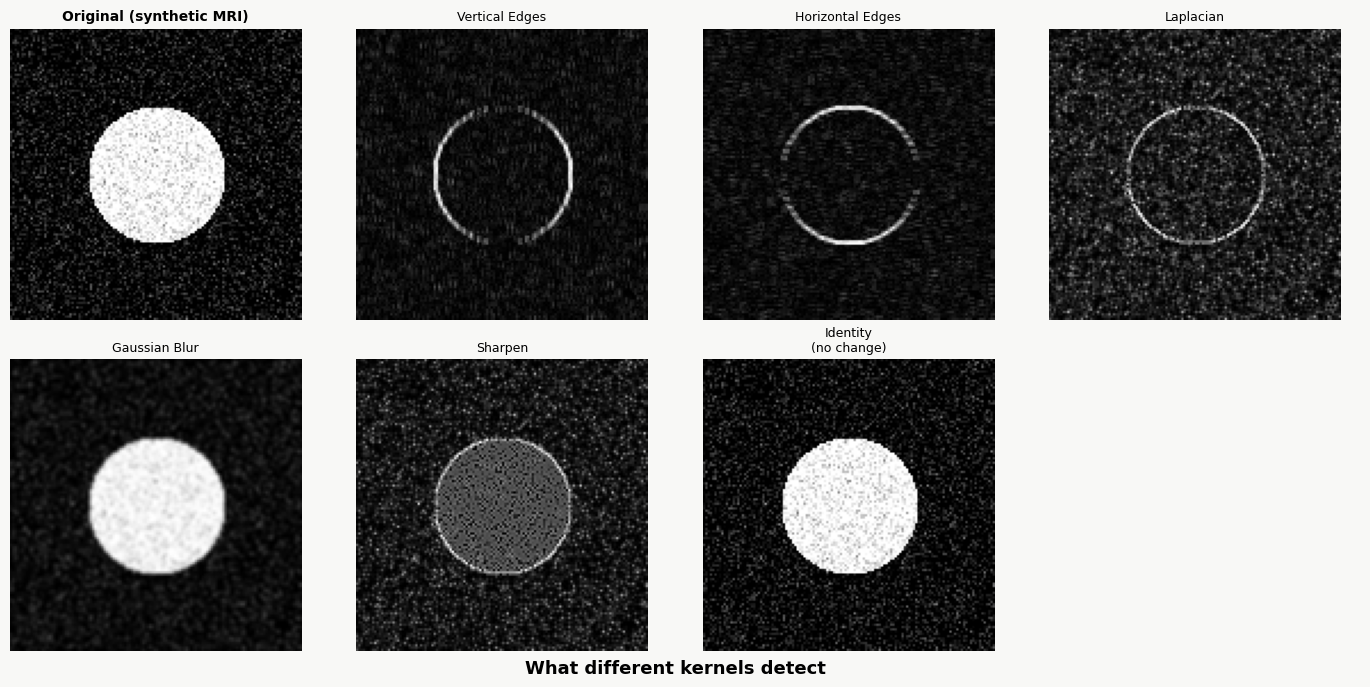

In [3]:
# 2. DIFFERENT KERNELS

#Creating a synthetic image
size = 128
y,x = np.ogrid[-size//2:size//2, -size//2:size//2]
circle = (x**2 + y**2 < 30**2).astype(np.float32)

rng = np.random.default_rng(42)
mri_like = circle + 0.15 * rng.standard_normal((size,size)).astype(np.float32)
mri_like = np.clip(mri_like,0,1)

fig,axes = plt.subplots(2,4,figsize = (14,7))
fig.patch.set_facecolor('#F8F8F6')
axes[0,0].imshow(mri_like,cmap='gray')
axes[0, 0].set_title("Original (synthetic MRI)", fontsize=10, fontweight='bold')
axes[0, 0].axis('off')

#Kernels
kernels={
    "Vertical Edges":np.array([[-1,0,1],[-1,0,1],[-1,0,1]],dtype = np.float32),
    "Horizontal Edges":np.array([[-1,-1,-1],[0,0,0],[1,1,1]],dtype = np.float32),
    "Laplacian":np.array([[0,-1,0],[-1,4,-1],[0,-1,0]],dtype = np.float32),
    "Gaussian Blur":np.array([[1,2,1],[2,4,2],[1,2,1]],dtype = np.float32),
    "Sharpen": np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=np.float32),
    "Identity\n(no change)": np.array([[0,0,0],[0,1,0],[0,0,0]], dtype=np.float32),
}

for ax, (name,k) in zip(list(axes.flatten())[1:],kernels.items()):
    out = manual_2dconv(mri_like,k,padding=1)
    out_display = np.abs(out)
    out_display = (out_display - out_display.min())/(out_display.max()-out_display.min()+ 1e-8)
    ax.imshow(out_display,cmap='gray')
    ax.set_title(name,fontsize=9)
    ax.axis('off')

axes[1,3].axis('off')
plt.suptitle("What different kernels detect", fontsize = 13, fontweight='bold',y=0.01)
plt.tight_layout()
plt.savefig("outputs/kernel_effects.png",dpi = 120,bbox_inches = 'tight',facecolor = fig.get_facecolor())


In [4]:
# 3. STRIDE AND PADDING EFFECTS

image_t = torch.tensor(mri_like)[None,None,:,:]
print(f"Input shape: {image_t.shape}")

configs = [
    ("K=3, P=0, S=1  (shrinks)", dict(kernel_size=3, padding=0, stride=1)),
    ("K=3, P=1, S=1  ('same')", dict(kernel_size=3, padding=1, stride=1)),
    ("K=3, P=0, S=2  (halves)", dict(kernel_size=3, padding=0, stride=2)),
    ("K=3, P=1, S=2  (halves, same-pad)", dict(kernel_size=3, padding=1, stride=2)),
    ("K=5, P=2, S=1  ('same', K=5)", dict(kernel_size=5, padding=2, stride=1)),
]

def output_size(W, K, P, S):
    return int((W - K + 2 * P) / S) + 1


for label,cfg in configs:
    conv = nn.Conv2d(1,1,**cfg,bias=False) #configuration in convolution, not ops
    with torch.no_grad():
        out = conv(image_t)
    K = cfg['kernel_size']
    P = cfg['padding']
    S = cfg['stride']
    formula = output_size(128,K,P,S)
    print(f"{label} -> actual:{tuple(out.shape)} formula:{formula}")

Input shape: torch.Size([1, 1, 128, 128])
K=3, P=0, S=1  (shrinks) -> actual:(1, 1, 126, 126) formula:126
K=3, P=1, S=1  ('same') -> actual:(1, 1, 128, 128) formula:128
K=3, P=0, S=2  (halves) -> actual:(1, 1, 63, 63) formula:63
K=3, P=1, S=2  (halves, same-pad) -> actual:(1, 1, 64, 64) formula:64
K=5, P=2, S=1  ('same', K=5) -> actual:(1, 1, 128, 128) formula:128


In [5]:
# 4. RECEPTIVE FIELD GROWTH
"""
Receptive Field (RF) = the region of the original input that
influences a single neuron's activation in a given layer.
 
With 3x3 kernels and stride=1:
  After layer 1: RF = 3x3   (sees a 3x3 patch directly)
  After layer 2: RF = 5x5   (each of the 3x3 inputs itself covers 3x3)
  After layer L: RF = (2L+1) x (2L+1)
 
Formula: RF_L = 1 + L * (K - 1)  for stride=1, K=kernel_size
"""

for L in range(1,9):
    rf = 1 + L*(3-1) #3x3 patch
    pct = rf/128*100
    bar = "█" * int(pct)
    print(f" Layer {L:2d}: RF= {rf:3d}x{rf:<3d}  ({pct:5.1f}% of 128px image)  {bar}")


print("\n  → By layer 6, a neuron sees 10% of the whole 128px image")
print("  → This is how early layers detect edges, deep layers detect tumour shapes")


 Layer  1: RF=   3x3    (  2.3% of 128px image)  ██
 Layer  2: RF=   5x5    (  3.9% of 128px image)  ███
 Layer  3: RF=   7x7    (  5.5% of 128px image)  █████
 Layer  4: RF=   9x9    (  7.0% of 128px image)  ███████
 Layer  5: RF=  11x11   (  8.6% of 128px image)  ████████
 Layer  6: RF=  13x13   ( 10.2% of 128px image)  ██████████
 Layer  7: RF=  15x15   ( 11.7% of 128px image)  ███████████
 Layer  8: RF=  17x17   ( 13.3% of 128px image)  █████████████

  → By layer 6, a neuron sees 10% of the whole 128px image
  → This is how early layers detect edges, deep layers detect tumour shapes


Raw activations   — mean: 4.982,  std: 12.020
After BatchNorm   — mean: 0.000,  std: 1.000


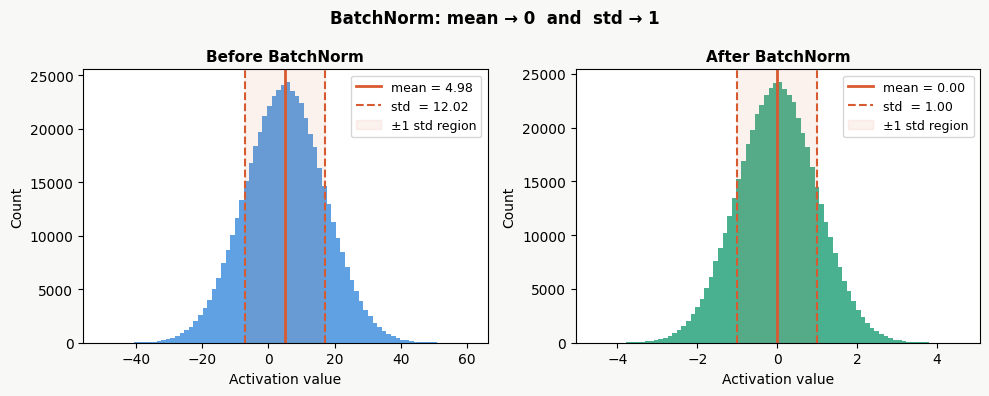

In [6]:
# 5. BATCHNORM
"""
Formula:
  1. μ_B  = mean of batch activations
  2. σ²_B = variance of batch activations
  3. x̂   = (x - μ_B) / sqrt(σ²_B + ε)    ← normalise
  4. y    = γ * x̂ + β                      ← scale & shift (learnable)
 
Why: Without it, activations can drift to very large/small values
     as weights update → gradients vanish or explode → training fails.
"""

# Simulate raw activations (as if from an untrained conv layer)
rng_t = torch.Generator()
rng_t.manual_seed(42)
raw_activations = torch.randn(32,64,16,16,generator=rng_t)*12 + 5.0 # mean≈5, std≈12

bn = nn.BatchNorm2d(64)
with torch.no_grad():
    normed = bn(raw_activations)

print(f"Raw activations   — mean: {raw_activations.mean():.3f},  std: {raw_activations.std():.3f}")
print(f"After BatchNorm   — mean: {normed.mean():.3f},  std: {normed.std():.3f}")

#Visulize distribution shift
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.patch.set_facecolor('#F8F8F6')
vals_before = raw_activations.flatten().numpy()
vals_after  = normed.detach().flatten().numpy()

for ax, vals, color, title in [
    (axes[0], vals_before, '#378ADD', "Before BatchNorm"),
    (axes[1], vals_after,  '#1D9E75', "After BatchNorm"),
]:
    mean = vals.mean()
    std  = vals.std()

    ax.hist(vals, bins=80, color=color, alpha=0.8, edgecolor='none')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel("Activation value")
    ax.set_ylabel("Count")

    # mean line
    ax.axvline(mean, color='#D85A30', lw=2, linestyle='-',
               label=f"mean = {mean:.2f}")

    # ── NEW: std shaded region (mean ± 1std) ──────────────────
    ax.axvline(mean + std, color='#D85A30', lw=1.5, linestyle='--',
               label=f"std  = {std:.2f}")
    ax.axvline(mean - std, color='#D85A30', lw=1.5, linestyle='--')
    ax.axvspan(mean - std, mean + std, alpha=0.08, color='#D85A30',
               label=f"±1 std region")

    ax.legend(fontsize=9)

plt.suptitle("BatchNorm: mean → 0  and  std → 1", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/batchnorm_effect.png", dpi=120,
            bbox_inches='tight', facecolor=fig.get_facecolor())


Vanishing gradient simulation (10 sigmoid layers, input=0.5):
  Layer  1: local grad = 0.2350,  cumulative = 0.23500371
  Layer  2: local grad = 0.2273,  cumulative = 0.05340837
  Layer  3: local grad = 0.2253,  cumulative = 0.01203252
  Layer  4: local grad = 0.2248,  cumulative = 0.00270536
  Layer  5: local grad = 0.2247,  cumulative = 0.00060799
  Layer  6: local grad = 0.2247,  cumulative = 0.00013662
  Layer  7: local grad = 0.2247,  cumulative = 0.00003070
  Layer  8: local grad = 0.2247,  cumulative = 0.00000690
  Layer  9: local grad = 0.2247,  cumulative = 0.00000155
  Layer 10: local grad = 0.2247,  cumulative = 0.00000035

Vanishing gradient simulation (10 ReLU layers, input=0.5):
  Layer  1: local grad = 1.0000,  cumulative = 1.00000000
  Layer  2: local grad = 1.0000,  cumulative = 1.00000000
  Layer  3: local grad = 1.0000,  cumulative = 1.00000000
  Layer  4: local grad = 1.0000,  cumulative = 1.00000000
  Layer  5: local grad = 1.0000,  cumulative = 1.00000000
  Layer

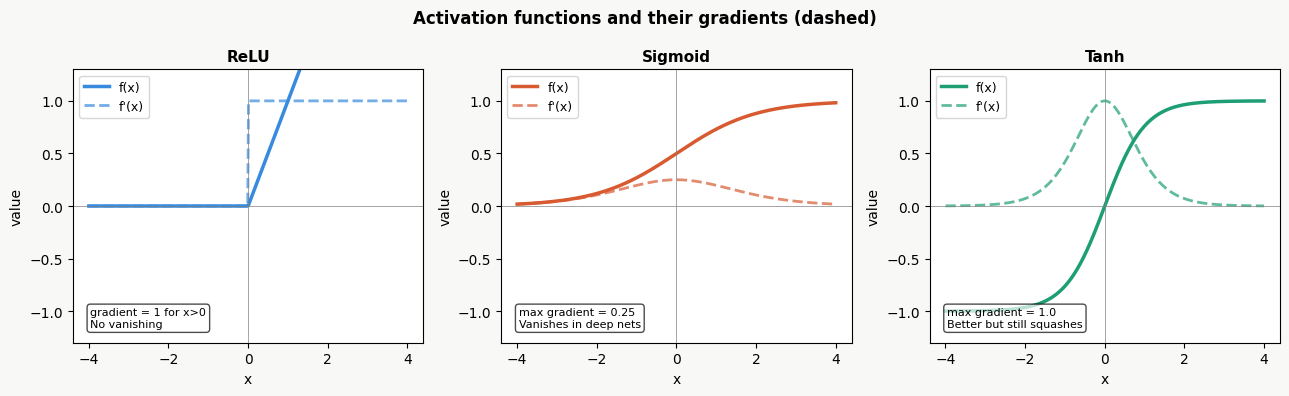

In [7]:
# 6. ACTIVATION FUNCTIONS — GRADIENT COMPARISON
"""
ReLU(x)    = max(0, x)           gradient = 1 if x>0, else 0
Sigmoid(x) = 1/(1+e^-x)         gradient = σ(x)*(1-σ(x))  ← max 0.25
Tanh(x)    = (e^x-e^-x)/(e^x+e^-x)  gradient = 1-tanh²(x) ← max 1.0
 
Problem with Sigmoid/Tanh:
  After 5 layers, gradient multiplied 5 times.
  If each gradient ≈ 0.25 (sigmoid max), total gradient = 0.25^5 ≈ 0.001
  → Weights barely update → vanishing gradient
  ReLU gradient is 1 for positive inputs → no vanishing
"""

x = torch.linspace(-4,4,400,requires_grad=False)
fig,axes = plt.subplots(1,3,figsize = (13,4))
fig.patch.set_facecolor('#F8F8F6')

acts = [
    ("ReLU", F.relu, '#378ADD', "gradient = 1 for x>0\nNo vanishing"),
    ("Sigmoid", torch.sigmoid, '#D85A30', "max gradient = 0.25\nVanishes in deep nets"),
    ("Tanh", torch.tanh, '#1D9E75', "max gradient = 1.0\nBetter but still squashes")
]

for ax,(name,fn,color,note) in zip(axes,acts):
    x_req = x.clone().requires_grad_(True)
    y= fn(x_req)

    #compute grad
    grads = []
    for xi in x:
        xi_r = xi.clone().requires_grad_(True)
        yi = fn(xi_r)
        yi.backward()
        grads.append(xi_r.grad.item())

    ax.plot(x.numpy(), y.detach().numpy(), color=color, lw=2.5, label='f(x)')
    ax.plot(x.numpy(), grads, color=color, lw=2, linestyle='--', alpha=0.7, label="f'(x)")
    ax.set_title(f"{name}", fontsize=11, fontweight='bold')
    ax.set_xlabel("x"); ax.set_ylabel("value")
    ax.legend(fontsize=9)
    ax.text(0.05, 0.05, note, transform=ax.transAxes, fontsize=8,
            verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_ylim(-1.3, 1.3)

plt.suptitle("Activation functions and their gradients (dashed)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/activations_gradients.png", dpi=120, bbox_inches='tight', facecolor=fig.get_facecolor())

#Vanishing gradients Numerically
#for sigmoid
print("\nVanishing gradient simulation (10 sigmoid layers, input=0.5):")
x_val = torch.tensor(0.5)
grad_product = 1.0
for layer in range(1,11):
    sig = torch.sigmoid(x_val)
    local_grad = (sig*(1-sig)).item()
    grad_product*=local_grad
    x_val = sig
    print(f"  Layer {layer:2d}: local grad = {local_grad:.4f},  cumulative = {grad_product:.8f}")


#for ReLU
print("\nVanishing gradient simulation (10 ReLU layers, input=0.5):")
x_val = torch.tensor(0.5)
grad_product = 1.0
for layer in range(1, 11):
    local_grad = 1.0 if x_val.item() > 0 else 0.0
    grad_product *= local_grad
    x_val = F.relu(x_val)
    print(f"  Layer {layer:2d}: local grad = {local_grad:.4f},  cumulative = {grad_product:.8f}")

Input shape:        (1, 1, 128, 128)
Feature maps shape: (1, 32, 128, 128)
→ 32 kernels x 1 input channel = 32 feature maps, each 128x128


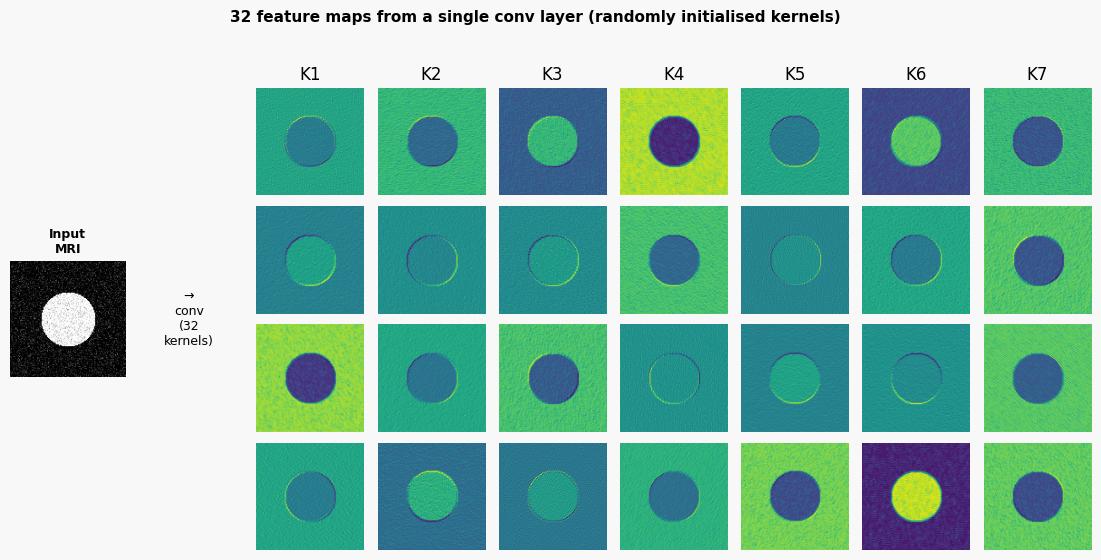

In [8]:
# 7. FEATURE MAPS
torch.manual_seed(0)
conv32 = nn.Conv2d(in_channels =1, out_channels=32,kernel_size=3,padding=1)
image_t = torch.tensor(mri_like)[None,None,:,:]

with torch.no_grad():
    feature_maps = conv32(image_t) #32 diff kernel convolutions

print(f"Input shape:        {tuple(image_t.shape)}")
print(f"Feature maps shape: {tuple(feature_maps.shape)}")
print(f"→ 32 kernels x 1 input channel = 32 feature maps, each 128x128")

fig = plt.figure(figsize=(14,6))
fig.patch.set_facecolor("#F8F8F8")
gs = gridspec.GridSpec(4,9,figure = fig,hspace=0.1,wspace=0.05)

ax0 = fig.add_subplot(gs[:, 0])
ax0.imshow(mri_like, cmap='gray')
ax0.set_title("Input\nMRI", fontsize=9, fontweight='bold')
ax0.axis('off')

ax_arrow = fig.add_subplot(gs[1:3, 1])
ax_arrow.text(0.5, 0.5, "→\nconv\n(32\nkernels)", ha='center', va='center',
              fontsize=9, transform=ax_arrow.transAxes)
ax_arrow.axis('off')

maps = feature_maps.squeeze().numpy()
for idx in range(32):
    row = idx//8
    col = (idx%8)+2
    if col<=8 :
        ax = fig.add_subplot(gs[row,col])
        fm = maps[idx]
        fm = (fm-fm.min())/(fm.max()-fm.min() + 1e-8)
        ax.imshow(fm)
        ax.axis('off')
        if idx<8:
            ax.set_title(f"K{idx+1}")

plt.suptitle("32 feature maps from a single conv layer (randomly initialised kernels)",
             fontsize=11, fontweight='bold', y=1.01)
plt.savefig("outputs/feature_maps.png", dpi=120, bbox_inches='tight', facecolor=fig.get_facecolor())

 

In [9]:
# 8. MAX POOLING
"""
MaxPool2d(2,2): divides the feature map into 2x2 blocks.
Keeps only the maximum value in each block.
 
Why max and not average?
  The maximum activation = the kernel DID detect its pattern there.
  Averaging dilutes this signal. Max is more aggressive and keeps
  the most important spatial information while halving H and W.
"""

example_fm = torch.tensor([
    [1.0, 3.0, 2.0, 1.0],
    [4.0, 6.0, 1.0, 2.0],
    [2.0, 1.0, 5.0, 3.0],
    [3.0, 2.0, 4.0, 8.0],
]).unsqueeze(0).unsqueeze(0)

maxpool = nn.MaxPool2d(kernel_size=2,stride=2)
avgpool = nn.AvgPool2d(kernel_size=2,stride=2)

pool_max = maxpool(example_fm)
pool_avg = avgpool(example_fm)

print("Input 4x4 feature map:")
print(example_fm.squeeze().numpy())
print(f"\nAfter MaxPool2d(2,2):")
print(pool_max.squeeze().numpy())
print(f"  ↑ top-left 2x2 max([1,3,4,6])=6  ← strong activation preserved")
print(f"\nAfter AvgPool2d(2,2):")
print(pool_avg.squeeze().numpy())
print(f"  ↑ top-left 2x2 avg([1,3,4,6])=3.5 ← diluted")

#Pooling on actual feature_map
sample_map = torch.tensor(maps[0])[None,None,:,:]
pooled_map = maxpool(sample_map)
print(f"\nReal feature map: {tuple(sample_map.shape)} → after MaxPool: {tuple(pooled_map.shape)}")



Input 4x4 feature map:
[[1. 3. 2. 1.]
 [4. 6. 1. 2.]
 [2. 1. 5. 3.]
 [3. 2. 4. 8.]]

After MaxPool2d(2,2):
[[6. 2.]
 [3. 8.]]
  ↑ top-left 2x2 max([1,3,4,6])=6  ← strong activation preserved

After AvgPool2d(2,2):
[[3.5 1.5]
 [2.  5. ]]
  ↑ top-left 2x2 avg([1,3,4,6])=3.5 ← diluted

Real feature map: (1, 1, 128, 128) → after MaxPool: (1, 1, 64, 64)


In [10]:
# 9. COMPLETE CONVBLOCK FORWARD PASS

class ConvBlock(nn.Module):
    """
    The fundamental building block of our CNN.
    
    Conv2d:     learns to detect spatial patterns (edges, textures, shapes)
    BatchNorm:  stabilises activations — critical for training from scratch
    ReLU:       introduces non-linearity, avoids vanishing gradients
    """
    def __init__(self, in_ch, out_ch, kernel_size=3,padding=1):
        super().__init__()
        self.conv = nn.Conv2d(in_ch,out_ch,kernel_size=kernel_size,padding=padding,bias=False)
        # bias=False because BatchNorm has its own learnable shift (β)
        # adding both would be redundant
        self.bn = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self,x):
        print(f"    Input:     {tuple(x.shape)}")
        x = self.conv(x)
        print(f"    After conv:{tuple(x.shape)}  (learned {self.conv.weight.numel()} weights)")
        x = self.bn(x)
        print(f"    After BN:  {tuple(x.shape)}  (normalised across batch)")
        x = self.relu(x)
        print(f"    After ReLU:{tuple(x.shape)}  (negatives zeroed)")
        return x

torch.manual_seed(7)
block = ConvBlock(in_ch=1,out_ch=32)
x = torch.randn(4,1,128,128) #batch of 4 greyscale channel mri imgs

print("\nForward pass through ConvBlock(in_ch=1, out_ch=32):")
print(f"  Batch: 4 images, 1 channel (grayscale), 128x128 px")
with torch.no_grad():
    out = block(x)
print(f"\n  Final output: {tuple(out.shape)}")
print(f"  Interpretation: 4 images, 32 feature maps each, still 128x128")

#Count parameters
total_params = sum(p.numel() for p in block.parameters())
conv_params = block.conv.weight.numel()
bn_params = sum(p.numel() for p in block.bn.parameters())
print(f"\n  Parameter count:")
print(f"    Conv2d weights:  {conv_params:,}   (32 kernels x 1 input ch x 3x3)")
print(f"    BatchNorm (γ,β): {bn_params:,}     (2 per channel x 32 channels)")
print(f"    Total:           {total_params:,}")



Forward pass through ConvBlock(in_ch=1, out_ch=32):
  Batch: 4 images, 1 channel (grayscale), 128x128 px
    Input:     (4, 1, 128, 128)
    After conv:(4, 32, 128, 128)  (learned 288 weights)
    After BN:  (4, 32, 128, 128)  (normalised across batch)
    After ReLU:(4, 32, 128, 128)  (negatives zeroed)

  Final output: (4, 32, 128, 128)
  Interpretation: 4 images, 32 feature maps each, still 128x128

  Parameter count:
    Conv2d weights:  288   (32 kernels x 1 input ch x 3x3)
    BatchNorm (γ,β): 64     (2 per channel x 32 channels)
    Total:           352


In [11]:
# 10. WEIGHT INITIALISATION
"""
If weights start too large → activations explode → NaN loss
If weights start too small → activations die → zero gradients
 
Kaiming He initialisation (designed for ReLU):
  W ~ N(0,  sqrt(2 / fan_in))
  fan_in = number of inputs to each neuron
  The sqrt(2) accounts for ReLU zeroing half the inputs on average.
"""
torch.manual_seed(42)
bad_init  = nn.Conv2d(1, 32, 3, padding=1)
nn.init.normal_(bad_init.weight, mean=0, std=1.0)  # bad: too large
good_init = nn.Conv2d(1, 32, 3, padding=1)
nn.init.kaiming_normal_(good_init.weight, mode='fan_in', nonlinearity='relu')

x_test = torch.randn(4, 1, 128, 128)
 
with torch.no_grad():
    out_bad  = F.relu(bad_init(x_test))
    out_good = F.relu(good_init(x_test))
 
print(f"Bad init  (std=1.0):    output mean={out_bad.mean():.3f},   std={out_bad.std():.3f}")
print(f"Kaiming init:           output mean={out_good.mean():.3f},   std={out_good.std():.3f}")
print(f"\n→ Bad init produces activations with std≈{out_bad.std():.1f} — explodes through many layers")
print(f"→ Kaiming keeps std≈{out_good.std():.2f} — stable through deep networks")

Bad init  (std=1.0):    output mean=1.100,   std=1.702
Kaiming init:           output mean=0.552,   std=0.837

→ Bad init produces activations with std≈1.7 — explodes through many layers
→ Kaiming keeps std≈0.84 — stable through deep networks


Convolution output size:
  (W - K + 2P) / S + 1
  
  'Same' padding:           P = (K-1) / 2  (for stride=1)
  
  Receptive field (3x3):   RF = 1 + 2*L after L layers
  
  ConvBlock param count (in=1, out=32, K=3):
  
    Conv weights = 32 × 1 × 3 × 3 = 288

    BN params    = 32 × 2 = 64  (gamma + beta)
    
    Total        = 352  ← very few for what it learns!
  
Sigmoid max gradient:     0.25  → vanishes after ~4 layers

ReLU gradient (x>0):      1.0   → stable through any depth
  
  **BatchNorm output:         mean≈0, std≈1 (per channel)**
  
  **Kaiming init std:         sqrt(2/fan_in)**
 
  Output files:
  
    outputs/kernel_effects.png       ← 6 kernel types on MRI-like image

    outputs/batchnorm_effect.png     ← activation distribution shift

    outputs/activations_gradients.png← ReLU vs Sigmoid vs Tanh
    
    outputs/feature_maps.png         ← 32 feature maps visualised